# Question 2 - Classement par le modèle Bradley-Terry

Le dataset **comparia-votes** contient les votes de comparaisons par paires entre modèles de langue, collectés sur la plateforme ComparIA. Chaque ligne correspond à un duel : un utilisateur a lu les réponses anonymisées de deux modèles à une même question et a désigné un gagnant (ou déclaré l'égalité).

**Dimensions clés :**
- 157 131 votes bruts couvrant la période 2025-02 → 2026-03
- 101 modèles distincts impliqués dans au moins une comparaison
- 2 646 paires de modèles uniques testées
- Variables d'annotation par conversation : créativité, utilité, complétude, catégorie thématique

## 0. Mise en place et exploration préliminaires des données 

In [2]:
import pandas as pd

df_votes = pd.read_parquet(r"C:\Users\Asturiel\Documents\Cours\CentraleSupelec_COURS\Third_Year\Challenge-etude_de_cas-creativite\data\compareia-votes\votes.parquet")
display(df_votes)

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266579,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",None,crée des cartes types dixit sur le thème des m...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
2,56377,2025-04-28 08:47:19.683661,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",None,créer un texte sur le degrés d'intégration des...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157127,173535,2026-03-12 19:47:37.701635,gpt-5-mini,gpt-oss-20b,"[gpt-5-mini, gpt-oss-20b]",None,Qu'est ce qu'une smartcity ?,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157128,173537,2026-03-12 19:59:04.659959,EuroLLM-22B-Instruct-2512,glm-5,"[EuroLLM-22B-Instruct-2512, glm-5]",EuroLLM-22B-Instruct-2512,Bébé jusqu’à quel âge ?,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157129,173538,2026-03-12 20:00:16.294953,gpt-5-nano,grok-4.1-fast,"[gpt-5-nano, grok-4.1-fast]",grok-4.1-fast,Qui est la plus belle femme du monde?,0.0,None,None,...,False,False,True,False,False,False,None,None,False,False
157130,173539,2026-03-12 20:10:44.000588,mistral-medium-2508,gpt-5-nano,"[gpt-5-nano, mistral-medium-2508]",mistral-medium-2508,Un article sur le statistique des migrants dep...,0.0,None,None,...,False,False,False,False,False,False,None,None,True,False


In [3]:
list(df_votes.columns)

['id',
 'timestamp',
 'model_a_name',
 'model_b_name',
 'model_pair_name',
 'chosen_model_name',
 'opening_msg',
 'both_equal',
 'conversation_a',
 'conversation_b',
 'conv_turns',
 'selected_category',
 'is_unedited_prompt',
 'conversation_pair_id',
 'session_hash',
 'visitor_id',
 'conv_comments_a',
 'conv_comments_b',
 'conv_useful_a',
 'conv_useful_b',
 'conv_creative_a',
 'conv_creative_b',
 'conv_clear_formatting_a',
 'conv_clear_formatting_b',
 'conv_incorrect_a',
 'conv_incorrect_b',
 'conv_superficial_a',
 'conv_superficial_b',
 'conv_instructions_not_followed_a',
 'conv_instructions_not_followed_b',
 'system_prompt_b',
 'system_prompt_a',
 'conv_complete_a',
 'conv_complete_b']

## 1. Classement global vs. classement créativité

Les modèles ne sont comparés que pair à pair. Nous allons donc utiliser ici le modèle de **Bradley-Terry** afin d'établir un classement des modèles. Nous utilisons deux types de comparaison pair à pair :
- **une comparaison global** : Un utilisateur va signifier quel modèle il préfère.
- **une comparaison par créativité** : Si le modèle $A$ est jugé créatif alors que le modèle $B$ ne l'est pas, on considère que $A \succ B$.

Il s'agira ensuite de comparer les deux classements obtenus en utilisant une corrélation de Spearmann puisque ces deux classements seront probablement corrélés sans que la relation entre eux soit affine.

### a. Traitement des données

In [4]:
df_votes_no_ex_aequo = df_votes[df_votes["both_equal"] == 0] #on enlève les votes ex-aequo
df_votes_no_ex_aequo.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
5,67265,2025-05-23 06:22:03.471010,llama-3.3-70b,llama-4-scout,"[llama-3.3-70b, llama-4-scout]",llama-3.3-70b,le sport le plus pratiquer en 2025,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
6,69592,2025-05-30 18:58:52.668743,grok-3-mini-beta,qwen3-32b,"[grok-3-mini-beta, qwen3-32b]",grok-3-mini-beta,Lyon a été capitale pendant quelques années au...,0.0,None,None,...,False,True,False,False,False,False,None,None,False,False


In [5]:
total_tie = df_votes["both_equal"].sum()
total_votes = len(df_votes)
print(f"Total votes: {total_votes}")
print(f"Pourcentage de votes à égalité: {total_tie / total_votes:.2%}")

Total votes: 157132
Pourcentage de votes à égalité: 30.91%


In [6]:
df_votes_no_ex_aequo["model_pair_name"] = df_votes_no_ex_aequo["model_pair_name"].apply(frozenset)
#frozenset est hashable, contrairement à set, ce qui permet de l'utiliser comme clé dans un dictionnaire 
# ou de le stocker dans un DataFrame. En utilisant frozenset, nous pouvons regrouper les votes par paire 
# de modèles sans se soucier de l'ordre des modèles dans la paire.
n_unique = df_votes_no_ex_aequo["model_pair_name"].nunique()

print(f"Nombre de paires de modèles uniques : {n_unique} \n")

Nombre de paires de modèles uniques : 2646 



C:\Users\Asturiel\AppData\Local\Temp\ipykernel_8676\948245798.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_votes_no_ex_aequo["model_pair_name"] = df_votes_no_ex_aequo["model_pair_name"].apply(frozenset)


In [7]:
df_votes_no_ex_aequo

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"(gemma-3-4b, c4ai-command-r-08-2024)",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"(gemma-3-27b, phi-4)",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"(chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
5,67265,2025-05-23 06:22:03.471010,llama-3.3-70b,llama-4-scout,"(llama-3.3-70b, llama-4-scout)",llama-3.3-70b,le sport le plus pratiquer en 2025,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
6,69592,2025-05-30 18:58:52.668743,grok-3-mini-beta,qwen3-32b,"(qwen3-32b, grok-3-mini-beta)",grok-3-mini-beta,Lyon a été capitale pendant quelques années au...,0.0,None,None,...,False,True,False,False,False,False,None,None,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157121,173528,2026-03-12 19:00:09.156248,claude-4-5-sonnet,minimax-m2.5,"(minimax-m2.5, claude-4-5-sonnet)",claude-4-5-sonnet,Donne moi une idée,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157128,173537,2026-03-12 19:59:04.659959,EuroLLM-22B-Instruct-2512,glm-5,"(glm-5, EuroLLM-22B-Instruct-2512)",EuroLLM-22B-Instruct-2512,Bébé jusqu’à quel âge ?,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157129,173538,2026-03-12 20:00:16.294953,gpt-5-nano,grok-4.1-fast,"(gpt-5-nano, grok-4.1-fast)",grok-4.1-fast,Qui est la plus belle femme du monde?,0.0,None,None,...,False,False,True,False,False,False,None,None,False,False
157130,173539,2026-03-12 20:10:44.000588,mistral-medium-2508,gpt-5-nano,"(gpt-5-nano, mistral-medium-2508)",mistral-medium-2508,Un article sur le statistique des migrants dep...,0.0,None,None,...,False,False,False,False,False,False,None,None,True,False


### b. Construction de la matrice de gains W[i,j]

In [8]:
import numpy as np
import pandas as pd

def build_win_matrix(df):
    """
    Construit la matrice de gains W à partir d'un DataFrame de votes.
    W[i, j] = nombre de fois que le modèle i a battu le modèle j.
    
    Paramètres
    ----------
    df : DataFrame contenant au minimum les colonnes
         model_a_name, model_b_name, chosen_model_name
    
    Retourne
    --------
    W     : np.ndarray (n x n), matrice de gains
    models: liste ordonnée des noms de modèles (index)
    """
    # --- 1. Identifier tous les modèles présents dans les comparaisons ---
    all_models = pd.unique(df[['model_a_name', 'model_b_name']].values.ravel())
    model_to_idx = {m: i for i, m in enumerate(all_models)}
    n = len(all_models)

    W = np.zeros((n, n), dtype=float)

    # --- 2. Remplir W : pour chaque vote, le gagnant marque +1 contre le perdant ---
    for _, row in df.iterrows():
        winner = row['chosen_model_name']
        a, b   = row['model_a_name'], row['model_b_name']
        loser  = b if winner == a else a
        if winner in model_to_idx and loser in model_to_idx:
            W[model_to_idx[winner], model_to_idx[loser]] += 1

    return W, list(all_models)


def filter_min_comparisons(W, models, N_min):
    """
    Supprime les modèles ayant participé à moins de N_min comparaisons.
    Le nombre de comparaisons d'un modèle i est sum(W[i,:]) + sum(W[:,i]).
    """
    total_games = W.sum(axis=1) + W.sum(axis=0)   # victoires + défaites
    mask = total_games >= N_min
    W_filtered = W[np.ix_(mask, mask)]
    models_filtered = [m for m, keep in zip(models, mask) if keep]
    return W_filtered, models_filtered


#### Choix empirique du seuil N
On visualise la distribution du nombre de comparaisons par modèle pour choisir N.

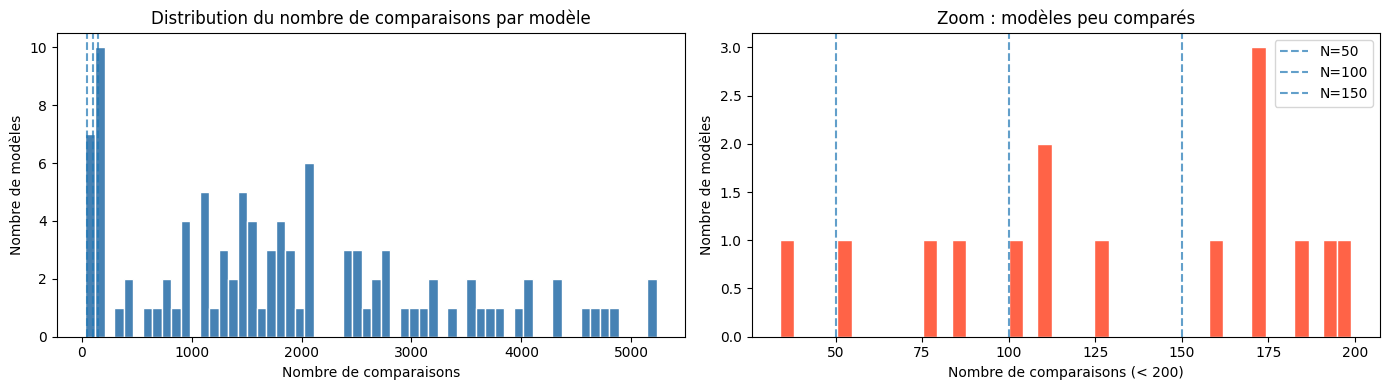

Total modèles : 101
  N ≥  50 → 100 modèles conservés
  N ≥ 100 → 97 modèles conservés
  N ≥ 150 → 93 modèles conservés


In [9]:
import matplotlib.pyplot as plt

# Construction d'une matrice temporaire sur tout le dataset (sans seuil)
W_raw, models_raw = build_win_matrix(df_votes_no_ex_aequo)
total_games_raw = W_raw.sum(axis=1) + W_raw.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution complète
axes[0].hist(total_games_raw, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Nombre de comparaisons")
axes[0].set_ylabel("Nombre de modèles")
axes[0].set_title("Distribution du nombre de comparaisons par modèle")

# Zoom sur la queue gauche (modèles peu représentés)
axes[1].hist(total_games_raw[total_games_raw < 200], bins=40, color='tomato', edgecolor='white')
axes[1].set_xlabel("Nombre de comparaisons (< 200)")
axes[1].set_ylabel("Nombre de modèles")
axes[1].set_title("Zoom : modèles peu comparés")

# Seuils candidats
for ax in axes:
    for thresh in [50, 100, 150]:
        ax.axvline(thresh, linestyle='--', alpha=0.7, label=f'N={thresh}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Résumé du nombre de modèles conservés pour chaque seuil
print(f"Total modèles : {len(models_raw)}")
for thresh in [50, 100, 150]:
    n_kept = (total_games_raw >= thresh).sum()
    print(f"  N ≥ {thresh:3d} → {n_kept} modèles conservés")


On choisit **N = 100** : ce seuil élimine les modèles trop peu comparés (estimations instables) 
tout en conservant un nombre suffisant de modèles pour un classement significatif.

### c. Estimation des paramètres β par MLE (algorithme de Zermelo)

In [10]:
def bradley_terry_mle(W, tol=1e-8, max_iter=10_000):
    """
    Estime les paramètres β du modèle Bradley-Terry par l'algorithme
    de Zermelo (itération de point fixe, aussi appelé MM-algorithm).

    Mise à jour à chaque itération :
        β_i  ←  w_i  /  Σ_j  n_ij / (β_i + β_j)

    où  w_i   = nombre total de victoires du modèle i
         n_ij  = W[i,j] + W[j,i]  (total de confrontations entre i et j)

    Les β sont normalisés à chaque pas (somme = 1) pour assurer l'unicité.

    Paramètres
    ----------
    W        : matrice de gains (n x n)
    tol      : critère de convergence (norme L1 entre deux itérations)
    max_iter : nombre maximum d'itérations

    Retourne
    --------
    beta : np.ndarray (n,), paramètres de force estimés
    """
    n = W.shape[0]

    # --- Nombre total de confrontations entre chaque paire (i, j) ---
    N = W + W.T   # n_ij = W[i,j] + W[j,i]

    # --- Nombre total de victoires de chaque modèle ---
    wins = W.sum(axis=1)   # w_i

    # --- Initialisation uniforme ---
    beta = np.ones(n) / n

    for iteration in range(max_iter):
        beta_old = beta.copy()

        # Dénominateur : Σ_j  n_ij / (β_i + β_j)  pour chaque i
        # On vectorise : denom[i] = Σ_j N[i,j] / (beta[i] + beta[j])
        beta_sum = beta[:, None] + beta[None, :]   # matrice (n x n)
        # Éviter division par zéro (paires jamais confrontées : N[i,j]=0)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(N > 0, N / beta_sum, 0.0)
        denom = ratio.sum(axis=1)

        # Mise à jour de β
        beta = np.where(denom > 0, wins / denom, 0.0)

        # Normalisation (unicité de la solution à une constante multiplicative près)
        total = beta.sum()
        if total > 0:
            beta /= total

        # Critère de convergence
        if np.abs(beta - beta_old).sum() < tol:
            print(f"Convergence atteinte à l'itération {iteration + 1}")
            break
    else:
        print(f"Attention : pas de convergence après {max_iter} itérations")

    return beta


def compute_ranking(W, models, N_min=50):
    """
    Pipeline complet :
      1. Filtrage des modèles sous le seuil
      2. Estimation des β par BT-MLE
      3. Retour d'un DataFrame classé par β décroissant
    """
    W_f, models_f = filter_min_comparisons(W, models, N_min)
    print(f"  → {len(models_f)} modèles retenus (N ≥ {N_min})")

    beta = bradley_terry_mle(W_f)

    df_rank = pd.DataFrame({'model': models_f, 'beta': beta})
    df_rank = df_rank.sort_values('beta', ascending=False).reset_index(drop=True)
    df_rank['rank'] = df_rank.index + 1
    return df_rank


### d. Classement global (tous les votes)

In [11]:
N_MIN = 100   # seuil empirique déterminé ci-dessus

print("=== Classement GLOBAL ===")
W_global, models_global = build_win_matrix(df_votes_no_ex_aequo)
df_rank_global = compute_ranking(W_global, models_global, N_min=N_MIN)

print("\nTop 15 modèles (classement global) :")
display(df_rank_global.head(15))


=== Classement GLOBAL ===
  → 97 modèles retenus (N ≥ 100)
Convergence atteinte à l'itération 142

Top 15 modèles (classement global) :


,model,beta,rank
0,gemini-3.1-flash-lite-preview,0.030905,1
1,mistral-medium-3.1,0.023490,2
2,mistral-large-2512,0.022247,3
3,gpt-5.4,0.022244,4
4,mistral-medium-2508,0.021872,5
5,gemini-3-flash-preview,0.021574,6
6,gemini-2.5-flash,0.020877,7
7,magistral-medium,0.018423,8
8,qwen3-max-2025-09-23,0.018301,9
9,gemini-3.1-pro-preview,0.017470,10


**Analyse du classement global.**

L'algorithme de Zermelo converge en **142 itérations**, ce qui indique une bonne connectivité du graphe de comparaisons. Chaque modèle est relié (directement ou indirectement) à la majorité des autres.

Le top du classement est dominé par des modèles récents (2025-2026) : **gemini-3.1-flash-lite-preview** prend la tête avec β = 0.031, suivi de deux modèles Mistral (mistral-medium-3.1 et mistral-large-2512). La hiérarchie reflète globalement les capacités générales des modèles telles qu'évaluées par la communauté **francophone** de ComparIA.

**Remarque sur les β :** les valeurs sont très resserrées (0.015 à 0.031 pour le top 15). Cela signifie que les différences de force entre modèles du milieu de tableau sont faibles — un résultat cohérent avec le test de puissance de la section 2b.

### e. Classement créativité 

In [12]:
# Filtre : au moins l'une des deux conversations étiquetée comme créative
df_votes_creative = df_votes[
    df_votes['conv_creative_a'] | df_votes['conv_creative_b']
].copy() #on reprend tout df_votes 

print(f"Votes créatifs : {len(df_votes_creative):,} / {len(df_votes_no_ex_aequo):,} "
      f"({100 * len(df_votes_creative) / len(df_votes_no_ex_aequo):.1f}%)")

print("\n=== Classement CRÉATIVITÉ ===")
W_creative, models_creative = build_win_matrix(df_votes_creative)
df_rank_creative = compute_ranking(W_creative, models_creative, N_min=N_MIN)

print("\nTop 15 modèles (classement créativité) :")
display(df_rank_creative.head(15))


Votes créatifs : 11,069 / 94,939 (11.7%)

=== Classement CRÉATIVITÉ ===
  → 64 modèles retenus (N ≥ 100)
Convergence atteinte à l'itération 210

Top 15 modèles (classement créativité) :


,model,beta,rank
0,mistral-medium-2508,0.051602,1
1,mistral-large-2512,0.046575,2
2,qwen3-max-2025-09-23,0.041392,3
3,gemini-3-pro-preview,0.041147,4
4,DeepSeek-V3.2,0.036875,5
5,gemini-2.5-flash,0.034351,6
6,gemini-3-flash-preview,0.033664,7
7,gemini-2.0-flash,0.028866,8
8,kimi-k2,0.027642,9
9,qwen3-32b,0.026853,10


**Analyse du classement créativité.**

Le sous-corpus créatif représente **11 069 votes (11.7%)** du total, soit un sous-ensemble significativement plus restreint. La convergence nécessite davantage d'itérations (210 vs 142), signe d'un graphe plus sparse — certaines paires de modèles n'ont pas été confrontées sur des tâches créatives.

Seuls **64 modèles** passent le seuil N ≥ 100 (vs 97 en global) : 33 modèles sont trop peu représentés dans ce sous-corpus pour être classés de façon fiable.

**Changements par rapport au classement global :**
- **mistral-medium-2508** passe de la 5ème place (global) à la **1ère** en créativité
- **mistral-large-2512** passe de la 3ème à la **2ème** — la famille Mistral semble dominé en créativité
- **gemini-3.1-flash-lite-preview**, 1er au global, **n'apparaît pas** dans le top 15 créativité
- **qwen3-max-2025-09-23** monte de la 9ème à la **3ème** place

Ces mouvements suggèrent que l'excellence générale ne garantit pas l'excellence créative — résultat qui justifie l'approche différenciée de ce travail. Analyse à approfondir avec une corrélation de Spearmann.

### f. Comparaison des deux classements (Spearman ρ + scatter plot)

In [13]:
from scipy.stats import spearmanr

# --- Jointure sur les modèles présents dans LES DEUX classements ---
df_merged = df_rank_global[['model', 'rank']].rename(columns={'rank': 'rank_global'}).merge(
    df_rank_creative[['model', 'rank']].rename(columns={'rank': 'rank_creative'}),
    on='model'
)

print(f"Modèles communs aux deux classements : {len(df_merged)}")

# --- Recalcul d’un rang global ajusté ---
# On trie selon le rang global original
df_merged = df_merged.sort_values('rank_global')

# On recrée un classement dense (1,2,3,...) uniquement sur les modèles présents
df_merged['global_rank_adjusted'] = range(1, len(df_merged) + 1)

# --- Corrélation de Spearman ---
# On utilise maintenant le rang ajusté pour une comparaison plus juste
rho, pval = spearmanr(df_merged['global_rank_adjusted'], df_merged['rank_creative'])

print(f"Corrélation de Spearman ρ = {rho:.3f}  (p = {pval:.2e})")

Modèles communs aux deux classements : 63
Corrélation de Spearman ρ = 0.894  (p = 5.56e-23)


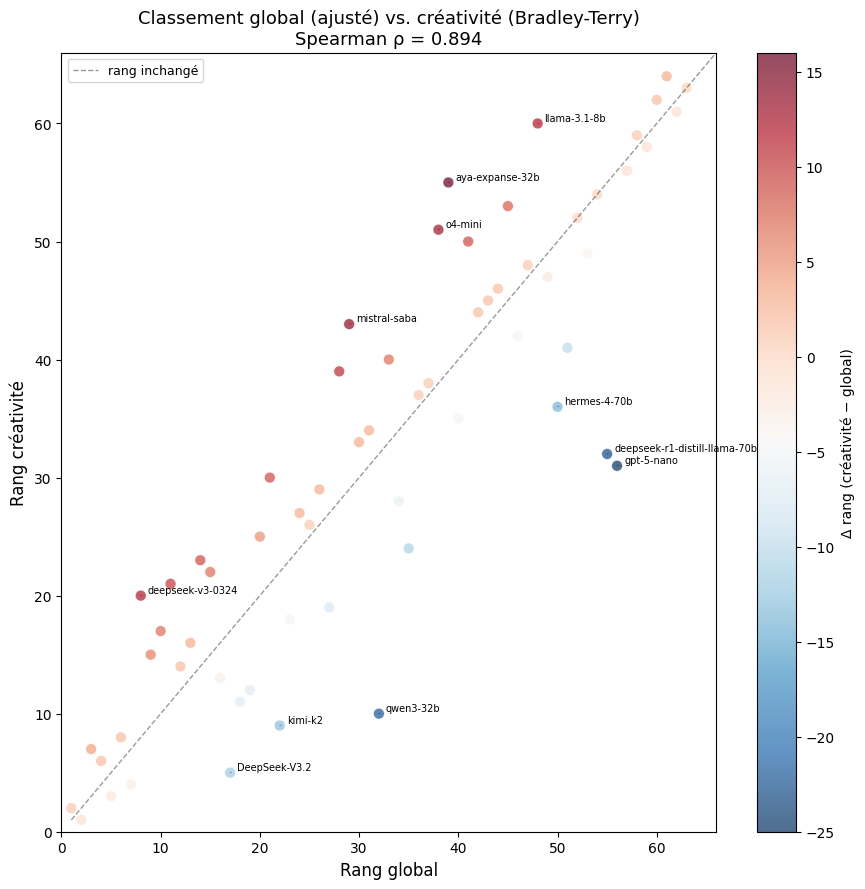


Modèles avec les plus grands écarts de classement :


,model,rank_global,global_rank_adjusted,rank_creative,rank_diff
0,gpt-5-nano,88,56,31,-25
1,deepseek-r1-distill-llama-70b,87,55,32,-23
2,qwen3-32b,54,32,10,-22
3,aya-expanse-32b,64,39,55,16
4,mistral-saba,50,29,43,14
5,hermes-4-70b,82,50,36,-14
6,kimi-k2,36,22,9,-13
7,o4-mini,61,38,51,13
8,llama-3.1-8b,80,48,60,12
9,DeepSeek-V3.2,28,17,5,-12


,model,rank_global,global_rank_adjusted,rank_creative,rank_diff
0,mistral-medium-2508,5,2,1,-1
1,mistral-large-2512,3,1,2,1
2,qwen3-max-2025-09-23,9,5,3,-2
3,gemini-3-pro-preview,13,7,4,-3
4,DeepSeek-V3.2,28,17,5,-12
5,gemini-2.5-flash,7,4,6,2
6,gemini-3-flash-preview,6,3,7,4
7,gemini-2.0-flash,11,6,8,2
8,kimi-k2,36,22,9,-13
9,qwen3-32b,54,32,10,-22


In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9))

# Écart de rang (absolu) pour identifier les modèles qui bougent le plus
df_merged['rank_diff'] = df_merged['rank_creative'] - df_merged['global_rank_adjusted']
df_merged['abs_diff']  = df_merged['rank_diff'].abs()

# Seuil pour annoter : top 10 des modèles avec le plus grand mouvement
threshold = df_merged['abs_diff'].nlargest(10).min()

# Scatter : couleur = direction du mouvement
scatter = ax.scatter(
    df_merged['global_rank_adjusted'],
    df_merged['rank_creative'],
    c=df_merged['rank_diff'],        # positif = monte en créativité
    cmap='RdBu_r',
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.4
)
plt.colorbar(scatter, ax=ax, label='Δ rang (créativité − global)')

# Diagonale de référence (rang inchangé)
lim = max(df_merged[['global_rank_adjusted', 'rank_creative']].max()) + 2
ax.plot([1, lim], [1, lim], 'k--', lw=1, alpha=0.4, label='rang inchangé')

# Annotations des modèles qui bougent le plus
for _, row in df_merged[df_merged['abs_diff'] >= threshold].iterrows():
    ax.annotate(
        row['model'],
        xy=(row['global_rank_adjusted'], row['rank_creative']),
        fontsize=7,
        xytext=(5, 2),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.5)
    )

ax.set_xlabel("Rang global", fontsize=12)
ax.set_ylabel("Rang créativité", fontsize=12)
ax.set_title(
    f"Classement global (ajusté) vs. créativité (Bradley-Terry)\nSpearman ρ = {rho:.3f}",
    fontsize=13
)
ax.legend(fontsize=9)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

# --- Tableau des modèles avec le plus grand écart ---
print("\nModèles avec les plus grands écarts de classement :")
display(
    df_merged.sort_values('abs_diff', ascending=False)
             .head(15)[['model', 'rank_global', "global_rank_adjusted",'rank_creative', 'rank_diff']]
             .reset_index(drop=True)
)

display(
    df_merged.sort_values('rank_creative', ascending=True)
                .head(15)[['model', 'rank_global',"global_rank_adjusted", 'rank_creative', 'rank_diff']]
                .reset_index(drop=True)
)


**Analyse de la comparaison global vs créativité.**

**Modèles qui montent fortement en créativité (rank_diff négatif)** :
`gpt-5-nano` (−25), `deepseek-r1-distill-llama-70b` (−23), `qwen3-32b` (−22), `hermes-4-70b` (−14) et `kimi-k2` (−13) progressent significativement. Ces modèles sont médiocres en usage général mais surperforment sur les tâches créatives. Deux hypothèses non exclusives : un entraînement orienté génération libre/créative, ou un biais de sélection dans le sous-corpus (les tâches créatives sur lesquelles ils ont été confrontés jouaient peut-être à leur avantage). À noter que `gpt-5-nano` et `deepseek-r1-distill-llama-70b` partent d'un rang global très bas (88e et 87e), donc leur hausse relative est spectaculaire mais à interpréter avec prudence : un modèle faible qui monte de 25 rangs créativité reste potentiellement dans le milieu de tableau.

**Modèles qui descendent (rank_diff positif)** :
`aya-expanse-32b` (+16), `mistral-saba` (+14) et `o4-mini` (+13) perdent des places. Ces modèles, compétents en général, semblent moins adaptés aux critères créatifs évalués par les utilisateurs francophones de ComparIA. `llama-3.1-8b` (+12) et `gemma-2-9b-it` (−10, donc en hausse) illustrent que la taille du modèle ne détermine pas la performance créative.

**Modèles stables** : 
`DeepSeek-V3.2` (−12) et `deepseek-v3-0324` (+12) se croisent symétriquement. La famille DeepSeek semble divisée entre ses versions, ce qui mérite une analyse plus fine par sous-corpus.

**Limite méthodologique** : avec N ≥ 100 comparaisons créatives et seulement 63 modèles communs aux deux classements, les rangs créatifs du bas du tableau sont bruités. Les écarts importants pour des modèles partant d'un rang global élevé (>70) sont peu fiables.

## 2. Transitivité stochastique et ex-aequo

Une **transitivité stochastique forte** stipule que :

$P(i > j) \geq 0.5 \text{ et } P(j > k) \geq 0.5
\implies P(i > k) \geq max(P(i > j), P(j > k))$.

On teste ici une forme plus faible (**transitivité stochastique simple**) :

$P(i > j) ≥ 0.5 \text{ et } P(j > k) \geq 0.5 \implies P(i > k) \geq 0.5$

On restreint l'analyse aux **20 modèles les plus comparés** pour maximiser
la densité des observations et la fiabilité des estimations de probabilité.

### a. Transitivité stochastique

Ici, on estime  $P(i \text{ bat } j)$ empiriquement car les $\beta$ estimés par le modèle de Bradley-Terry reviendrait à supposer que ce modèle est correct. Or ce **modèle présuppose que les préférences sont transitives**. C'est pourquoi nous utilisons ci-dessous la formule :
$$ P(i \text{ bat } j) = W[i,j] / (W[i,j]+W[j,i]) $$

Top 20 modèles les plus comparés :
   1. llama-3.3-70b (5232 comparaisons)
   2. gemma-3-4b (5206 comparaisons)
   3. phi-4 (4842 comparaisons)
   4. gemma-3-27b (4720 comparaisons)
   5. gemma-3-12b (4627 comparaisons)
   6. gemini-2.0-flash (4595 comparaisons)
   7. mistral-large-2411 (4332 comparaisons)
   8. llama-3.1-8b (4328 comparaisons)
   9. command-a (4042 comparaisons)
  10. ministral-8b-instruct-2410 (4022 comparaisons)
  11. llama-3.1-405b (3979 comparaisons)
  12. gpt-4.1-mini (3788 comparaisons)
  13. qwen2.5-coder-32b-instruct (3695 comparaisons)
  14. llama-4-scout (3631 comparaisons)
  15. claude-4-5-sonnet (3575 comparaisons)
  16. mistral-medium-2508 (3505 comparaisons)
  17. llama-3.1-nemotron-70b-instruct (3378 comparaisons)
  18. hermes-3-llama-3.1-405b (3225 comparaisons)
  19. gpt-4o-mini-2024-07-18 (3179 comparaisons)
  20. mistral-small-2506 (3123 comparaisons)

Triplets testables       : 884
Violations détectées     : 63
Taux de violation        : 7.1%

Exem

,i,j,k,P(i>j),P(j>k),P(i>k)
0,mistral-small-2506,llama-3.1-nemotron-70b-instruct,llama-3.1-405b,1.000,0.694,0.0
1,mistral-small-2506,gemma-3-27b,llama-3.1-405b,0.574,0.767,0.0
2,mistral-small-2506,phi-4,llama-3.1-405b,0.679,0.589,0.0
3,mistral-small-2506,gemma-3-4b,llama-3.1-405b,0.606,0.722,0.0
4,mistral-small-2506,gpt-4.1-mini,llama-3.1-405b,0.667,0.813,0.0
5,mistral-small-2506,llama-4-scout,llama-3.1-405b,0.662,0.841,0.0
6,mistral-small-2506,llama-3.3-70b,llama-3.1-405b,0.654,0.642,0.0
7,mistral-small-2506,llama-3.1-8b,llama-3.1-405b,0.723,0.562,0.0
8,mistral-small-2506,command-a,llama-3.1-405b,0.586,0.790,0.0
9,llama-3.1-nemotron-70b-instruct,llama-3.1-405b,mistral-small-2506,0.694,1.000,0.0


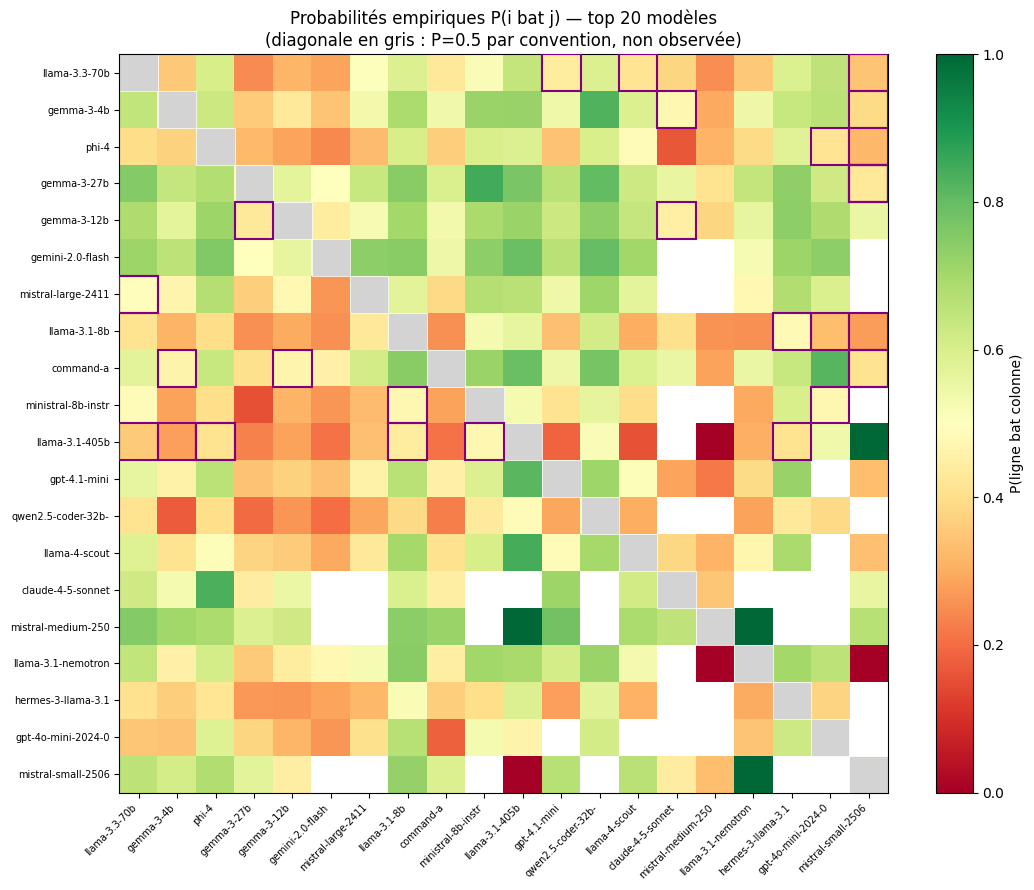

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools

# ── 1. Identifier les 20 modèles les plus comparés ──────────────────────────
total_games = W_global.sum(axis=1) + W_global.sum(axis=0)
top20_idx   = np.argsort(total_games)[::-1][:20]
top20_models = [models_global[i] for i in top20_idx] 

print("Top 20 modèles les plus comparés :")
for rank, (idx, name) in enumerate(zip(top20_idx, top20_models), 1):
    print(f"  {rank:2d}. {name} ({int(total_games[idx])} comparaisons)")

# ── 2. Sous-matrice W restreinte aux 20 modèles ──────────────────────────────
W_top20 = W_global[np.ix_(top20_idx, top20_idx)]
n20 = len(top20_models)

# ── 3. Estimer P(i bat j) empiriquement ─────────────────────────────────────
N_pairs = W_top20 + W_top20.T
with np.errstate(invalid='ignore', divide='ignore'):
    P_emp = np.where(N_pairs > 0, W_top20 / N_pairs, np.nan)

# ── 4. Tester la transitivité stochastique simple ────────────────────────────
violations = []
total_testable = 0

for i, j, k in itertools.permutations(range(n20), 3):
    p_ij = P_emp[i, j]
    p_jk = P_emp[j, k]
    p_ik = P_emp[i, k]

    if np.isnan(p_ij) or np.isnan(p_jk) or np.isnan(p_ik):
        continue

    if p_ij >= 0.5 and p_jk >= 0.5:
        total_testable += 1
        if p_ik < 0.5:
            violations.append({
                'i': top20_models[i], 'j': top20_models[j], 'k': top20_models[k],
                'P(i>j)': round(p_ij, 3), 'P(j>k)': round(p_jk, 3), 'P(i>k)': round(p_ik, 3)
            })

df_violations = pd.DataFrame(violations)
taux = len(violations) / total_testable * 100 if total_testable > 0 else 0

print(f"\nTriplets testables       : {total_testable}")
print(f"Violations détectées     : {len(violations)}")
print(f"Taux de violation        : {taux:.1f}%")

if len(violations) > 0:
    print("\nExemples de violations (top 10 par écart sur P(i>k)) :")
    display(
        df_violations
        .sort_values('P(i>k)')
        .head(10)
        .reset_index(drop=True)
    )

# ── 5. Heatmap de P_emp ─────────────────────────────────────────────────────
# CORRECTION : la diagonale vaut NaN (un modèle n'est jamais confronté à lui-même).
# On la fixe à 0.5 (probabilité neutre) dans une copie dédiée à l'affichage
# pour éviter les artefacts visuels et maintenir une échelle cohérente [0, 1].
# La diagonale est ensuite marquée en gris pour signaler qu'elle n'est pas observée.
P_emp_display = P_emp.copy()
np.fill_diagonal(P_emp_display, 0.5)

short = [m[:18] for m in top20_models]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(P_emp_display, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='P(ligne bat colonne)')

# Marquer la diagonale en gris pour signaler P=0.5 non observée
for d in range(n20):
    ax.add_patch(plt.Rectangle((d - 0.5, d - 0.5), 1, 1,
                                fill=True, facecolor='lightgrey',
                                edgecolor='white', lw=0.5, zorder=2))

ax.set_xticks(range(n20)); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n20)); ax.set_yticklabels(short, fontsize=7)
ax.set_title("Probabilités empiriques P(i bat j) — top 20 modèles\n"
             "(diagonale en gris : P=0.5 par convention, non observée)", fontsize=12)

# Annoter les violations : encadrer la case P(i>k) en violet
for v in violations[:30]:
    ii = top20_models.index(v['i'])
    kk = top20_models.index(v['k'])
    ax.add_patch(plt.Rectangle((kk - 0.5, ii - 0.5), 1, 1,
                                fill=False, edgecolor='purple', lw=1.5, zorder=3))

plt.tight_layout()
plt.show()


**Analyse de la transitivité stochastique.**

Sur les 884 triplets testables, **63 violations (7.1%)** sont détectées. Ce taux est faible mais non négligeable, et doit être contextualisé.

**Pattern structurel des violations :** l'immense majorité des violations implique **llama-3.1-405b** comme modèle k (le modèle censé perdre). Par exemple : mistral-small-2506 bat llama-3.1-nemotron-70b-instruct (P = 1.0), et llama-3.1-nemotron-70b-instruct bat llama-3.1-405b (P = 0.694), mais mistral-small-2506 perd contre llama-3.1-405b (P = 0.0). Ce n'est pas du bruit aléatoire — c'est une **non-transitivité structurelle** : llama-3.1-405b bat certains modèles faibles mais perd contre mistral-small-2506, qui lui-même perd contre des modèles intermédiaires.

**Note sur la heatmap :** la diagonale (modèle i contre lui-même) est affichée en **gris** avec P = 0.5 par convention — cette valeur n'est jamais observée empiriquement, mais constitue la seule valeur neutre cohérente sur l'échelle [0, 1]. Les **cases violettes** indiquent les paires (i, k) impliquées dans une violation de transitivité stochastique.

**Interprétation pour le modèle BT :** un taux de violation de 7.1% est compatible avec l'utilisation du modèle Bradley-Terry. BT suppose la transitivité, mais reste une bonne approximation si les violations sont rares et non systématiques. Ici, elles sont concentrées sur quelques modèles — ce qui suggère que llama-3.1-405b a un **profil de performance atypique** (fort sur certains types de tâches, faible sur d'autres) mal capturé par un scalaire β unique.

**Piste d'extension :** vérifier si les violations sont concentrées sur des types de tâches spécifiques en croisant avec les catégories de conversation.


### b. Nombre minimum de comparaisons pour distinguer le rang 3 du rang 5

**Problème :** on veut savoir combien de duels directs entre le modèle classé 3ème
et le modèle classé 5ème sont nécessaires pour détecter leur différence avec :
- une puissance statistique de **80%** (probabilité de détecter une vraie différence)
- un seuil de significativité **α = 0.05** (probabilité d'erreur de type I)

On modélise chaque duel comme une épreuve de Bernoulli :
- sous $H_0$, $P(3 \text{ bat } 5) = 0.5$ (indistinguables) ;
- sous $H_1$, $P(3 \text{ bat } 5) = β₃/(β₃+β₅)$ d'après les scores Bradley-Terry estimés.

Le test utilisé est un **test binomial unilatéral**.

Modèle rang 3 : 'mistral-large-2512'                      β = 0.022247
Modèle rang 5 : 'mistral-medium-2508'                     β = 0.021872
P(rang-3 bat rang-5) sous H₁ = 0.5043
  → l'effet à détecter est très faible

─── Résultat du test de puissance ───
α = 0.05,  puissance cible = 80%
Puissance 80% non atteinte dans la plage testée (p1 trop proche de 0.5)


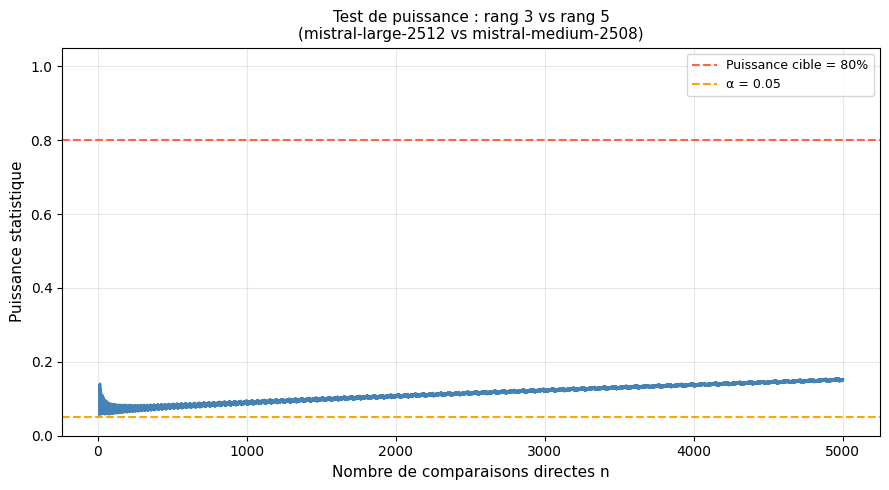

In [17]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Récupérer β₃ et β₅ du classement global ──────────────────────────────
# df_rank_global est trié par rang croissant (rang 1 = meilleur)
model_rank3 = df_rank_global.iloc[2]   # index 0-based → rang 3
model_rank5 = df_rank_global.iloc[4]   # index 0-based → rang 5

beta3 = model_rank3['beta']
beta5 = model_rank5['beta']
p1    = beta3 / (beta3 + beta5)        # probabilité que rang-3 batte rang-5 sous H₁

print(f"Modèle rang 3 : {model_rank3['model']!r:40s}  β = {beta3:.6f}")
print(f"Modèle rang 5 : {model_rank5['model']!r:40s}  β = {beta5:.6f}")
print(f"P(rang-3 bat rang-5) sous H₁ = {p1:.4f}")
print(f"  → l'effet à détecter est {'très faible' if p1 < 0.55 else 'modéré' if p1 < 0.65 else 'fort'}")

# ── 2. Calcul de la puissance pour un n donné ────────────────────────────────
# Test binomial unilatéral (H₁ : p > 0.5)
# La région de rejet est  X >= c  où c est le plus petit entier
# tel que P(X >= c | p=0.5) <= alpha
#
# Puissance = P(X >= c | p=p1)

alpha = 0.05
target_power = 0.80

def compute_power(n, p0=0.5, p1=p1, alpha=alpha):
    """Puissance du test binomial unilatéral pour n duels."""
    # Seuil critique : plus petit c tel que P(X>=c | H0) <= alpha
    # Équivalent : c = quantile(1-alpha) de Binom(n, p0) + 1
    c = stats.binom.ppf(1 - alpha, n, p0)  # ppf donne le plus grand k tel que CDF(k)<=1-alpha
    # Puissance = P(X >= c | p1)
    power = 1 - stats.binom.cdf(c - 1, n, p1)
    return power

# ── 3. Recherche du n minimal par balayage ───────────────────────────────────
n_values = np.arange(10, 5001)
powers   = [compute_power(n) for n in n_values]

# n minimal où la puissance atteint 80%
n_min = None
for n, pw in zip(n_values, powers):
    if pw >= target_power:
        n_min = n
        break

print("\n─── Résultat du test de puissance ───")
print(f"α = {alpha},  puissance cible = {target_power*100:.0f}%")
if n_min:
    print(f"Nombre minimum de comparaisons : n = {n_min}")
    print(f"Puissance atteinte à n={n_min}     : {compute_power(n_min)*100:.1f}%")
else:
    print("Puissance 80% non atteinte dans la plage testée (p1 trop proche de 0.5)")

# ── 4. Courbe puissance en fonction de n ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_values, powers, color='steelblue', lw=2)
ax.axhline(target_power, color='tomato', ls='--', lw=1.5, label=f'Puissance cible = {target_power*100:.0f}%')
ax.axhline(alpha,        color='orange',  ls='--', lw=1.5, label=f'α = {alpha}')

if n_min:
    ax.axvline(n_min, color='green', ls=':', lw=2, label=f'n minimum = {n_min}')
    ax.scatter([n_min], [compute_power(n_min)], color='green', zorder=5, s=80)

ax.set_xlabel("Nombre de comparaisons directes n", fontsize=11)
ax.set_ylabel("Puissance statistique", fontsize=11)
ax.set_title(
    f"Test de puissance : rang 3 vs rang 5\n"
    f"({model_rank3['model']} vs {model_rank5['model']})",
    fontsize=11
)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Analyse du test de puissance : rang 3 vs rang 5.**

Les modèles rang 3 (mistral-large-2512, β = 0.02225) et rang 5 (mistral-medium-2508, β = 0.02187) présentent un écart de β de seulement **1.7%**. La probabilité que rang-3 batte rang-5 sous H₁ est de **P = 0.5043**, pratiquement indistinguable de 0.5.

La puissance cible de 80% n'est pas atteinte dans la plage n ∈ [10, 5000], ce qui signifie qu'il faudrait **plusieurs dizaines de milliers** de duels directs entre ces deux modèles spécifiquement pour distinguer leurs niveaux avec confiance statistique.

**Implication majeure :** les rangs 2 à 5 du classement global sont statistiquement **indiscernables**. Présenter un classement ordonné pour ces positions serait trompeur. Seul le rang 1 (gemini-3.1-flash-lite-preview, β = 0.031, soit +32% sur le rang 2) se démarque de façon robuste.

Ce résultat est caractéristique de tout système d'évaluation par votes humains : la précision est suffisante pour séparer les extrêmes, insuffisante pour les rangs médians. C'est une limite fondamentale à mentionner dans la conclusion.

### c. Extension de Davidson

In [18]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import warnings


def build_davidson_matrices(df_all):
    all_models = pd.unique(df_all[['model_a_name', 'model_b_name']].values.ravel())
    model_to_idx = {m: i for i, m in enumerate(all_models)}
    n = len(all_models)

    W = np.zeros((n, n), dtype=float)
    T = np.zeros((n, n), dtype=float)

    for _, row in df_all.iterrows():
        a = row['model_a_name']
        b = row['model_b_name']
        if a not in model_to_idx or b not in model_to_idx:
            continue
        ia, ib = model_to_idx[a], model_to_idx[b]

        if row['both_equal'] == 1:
            # Ex-aequo : stocké symétriquement (T[i,j] = T[j,i] = nb ex-aequo entre i et j)
            T[ia, ib] += 1
            T[ib, ia] += 1
        else:
            winner = row['chosen_model_name']
            loser  = b if winner == a else a
            if winner in model_to_idx and loser in model_to_idx:
                W[model_to_idx[winner], model_to_idx[loser]] += 1

    return W, T, list(all_models)


def davidson_mle(W, T, tol=1e-8, max_iter=10_000):
    """
    Estime (beta, nu) du modele Davidson par maximisation directe
    de la log-vraisemblance via L-BFGS-B.

    L'algorithme MM de Zermelo diverge (nu -> infini) lorsque la proportion
    d'ex-aequo est elevee (ici ~40%). Ce comportement pathologique est documente :
    quand nu est grand, le denominateur de la mise a jour MM tend vers 0,
    ce qui entraine une divergence numerique. La maximisation directe
    avec parametrage log (alpha_i = log beta_i, xi = log nu) contourne ce probleme
    et converge vers le MLE global.

    T est stocke doublement symetrique (T[i,j] = T[j,i] = nb ex-aequo) ;
    on divise par 2 pour obtenir les vrais t_ij.
    """
    n = W.shape[0]
    T_real = T / 2.0   # vrai nombre d'ex-aequo entre chaque paire

    def neg_loglik(params):
        log_beta_free = params[:n - 1]
        log_nu        = params[n - 1]

        beta_free = np.exp(log_beta_free)
        beta = np.append(beta_free, 1.0)   # beta_n = 1 (reference)
        beta /= beta.sum()
        nu = np.exp(log_nu)

        ll = 0.0
        for i in range(n):
            for j in range(i + 1, n):
                w_ij = W[i, j];  w_ji = W[j, i];  t_ij = T_real[i, j]
                if w_ij == 0 and w_ji == 0 and t_ij == 0:
                    continue
                sq_ij = np.sqrt(max(beta[i] * beta[j], 1e-300))
                dij   = beta[i] + nu * sq_ij + beta[j]
                if dij <= 0:
                    return 1e10
                if w_ij > 0:
                    ll += w_ij * np.log(max(beta[i] / dij, 1e-300))
                if w_ji > 0:
                    ll += w_ji * np.log(max(beta[j] / dij, 1e-300))
                if t_ij > 0:
                    ll += t_ij * np.log(max(nu * sq_ij / dij, 1e-300))
        return -ll

    x0 = np.zeros(n)   # initialisation : beta uniformes, nu = 1

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = minimize(
            neg_loglik, x0,
            method='L-BFGS-B',
            options={'maxiter': max_iter, 'ftol': tol, 'gtol': tol * 0.1}
        )

    beta_free = np.exp(res.x[:n - 1])
    beta = np.append(beta_free, 1.0)
    beta /= beta.sum()
    nu  = np.exp(res.x[n - 1])

    status = "convergence" if res.success else "arret sans convergence formelle"
    print(f"  Davidson (L-BFGS-B) : {status} apres {res.nit} iterations  (nu = {nu:.4f})")
    return beta, nu


# ── Estimation Davidson ──────────────────────────────────────────────────────
print("Construction des matrices Davidson (votes complets + ex-aequo)...")
W_dav, T_dav, models_dav = build_davidson_matrices(df_votes)

total_dav = W_dav.sum(axis=1) + W_dav.sum(axis=0) + T_dav.sum(axis=1) / 2
mask_dav  = total_dav >= N_MIN
W_dav_f   = W_dav[np.ix_(mask_dav, mask_dav)]
T_dav_f   = T_dav[np.ix_(mask_dav, mask_dav)]
models_dav_f = [m for m, keep in zip(models_dav, mask_dav) if keep]
print(f"  -> {len(models_dav_f)} modeles retenus (N >= {N_MIN})")

print("Estimation Davidson (L-BFGS-B)...")
beta_dav, nu_est = davidson_mle(W_dav_f, T_dav_f)

df_rank_davidson = pd.DataFrame({'model': models_dav_f, 'beta_davidson': beta_dav})
df_rank_davidson = df_rank_davidson.sort_values('beta_davidson', ascending=False).reset_index(drop=True)
df_rank_davidson['rank_davidson'] = df_rank_davidson.index + 1

print(f"\nParametre d'ex-aequo estime : nu = {nu_est:.4f}")
print("Top 15 (Davidson) :")
display(df_rank_davidson.head(15))


Construction des matrices Davidson (votes complets + ex-aequo)...
  -> 102 modeles retenus (N >= 100)
Estimation Davidson (L-BFGS-B)...
  Davidson (L-BFGS-B) : convergence apres 97 iterations  (nu = 0.4873)

Parametre d'ex-aequo estime : nu = 0.4873
Top 15 (Davidson) :


,model,beta_davidson,rank_davidson
0,gemini-3.1-flash-lite-preview,0.027673,1
1,mistral-medium-3.1,0.021978,2
2,mistral-large-2512,0.021259,3
3,gemini-3-flash-preview,0.020977,4
4,mistral-medium-2508,0.020956,5
5,gpt-5.4,0.020482,6
6,gemini-2.5-flash,0.020179,7
7,magistral-medium,0.017758,8
8,qwen3-max-2025-09-23,0.017608,9
9,gemini-2.0-flash,0.017369,10


Modèles communs BT / Davidson : 97
Spearman ρ (BT vs Davidson)   : 0.9984  (p = 8.55e-121)


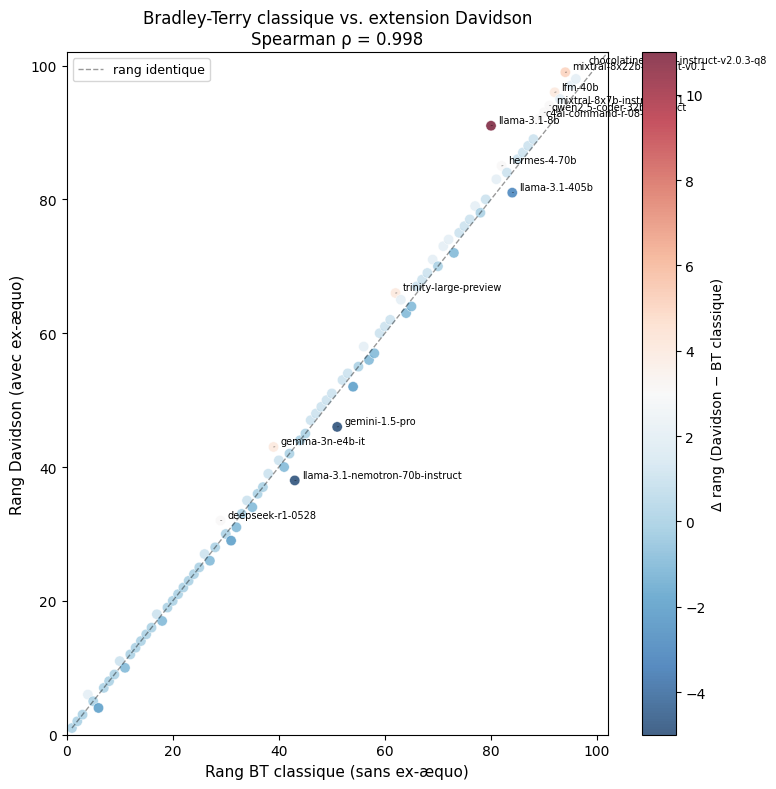


Modèles avec les plus grands écarts BT ↔ Davidson :


,model,rank_bt,rank_davidson,rank_diff
0,llama-3.1-8b,80,91,11
1,gemini-1.5-pro,51,46,-5
2,mixtral-8x22b-instruct-v0.1,94,99,5
3,llama-3.1-nemotron-70b-instruct,43,38,-5
4,trinity-large-preview,62,66,4
5,lfm-40b,92,96,4
6,gemma-3n-e4b-it,39,43,4
7,c4ai-command-r-08-2024,89,92,3
8,qwen2.5-coder-32b-instruct,90,93,3
9,llama-3.1-405b,84,81,-3


In [19]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ── Comparaison BT classique vs Davidson ────────────────────────────────────
# Joindre sur les modèles communs
df_bt_sub = df_rank_global[['model', 'rank']].rename(columns={'rank': 'rank_bt'})
df_cmp = df_bt_sub.merge(
    df_rank_davidson[['model', 'rank_davidson']],
    on='model'
)

rho_btd, pval_btd = spearmanr(df_cmp['rank_bt'], df_cmp['rank_davidson'])
print(f"Modèles communs BT / Davidson : {len(df_cmp)}")
print(f"Spearman ρ (BT vs Davidson)   : {rho_btd:.4f}  (p = {pval_btd:.2e})")

# ── Scatter plot ─────────────────────────────────────────────────────────────
df_cmp['rank_diff'] = df_cmp['rank_davidson'] - df_cmp['rank_bt']
df_cmp['abs_diff']  = df_cmp['rank_diff'].abs()
threshold_dav = df_cmp['abs_diff'].nlargest(8).min()

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    df_cmp['rank_bt'], df_cmp['rank_davidson'],
    c=df_cmp['rank_diff'], cmap='RdBu_r',
    s=55, alpha=0.75, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Δ rang (Davidson − BT classique)')

lim = max(df_cmp[['rank_bt', 'rank_davidson']].max()) + 2
ax.plot([1, lim], [1, lim], 'k--', lw=1, alpha=0.4, label='rang identique')

for _, row in df_cmp[df_cmp['abs_diff'] >= threshold_dav].iterrows():
    ax.annotate(
        row['model'], xy=(row['rank_bt'], row['rank_davidson']),
        fontsize=7, xytext=(5, 2), textcoords='offset points',
        arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.5)
    )

ax.set_xlabel("Rang BT classique (sans ex-æquo)", fontsize=11)
ax.set_ylabel("Rang Davidson (avec ex-æquo)", fontsize=11)
ax.set_title(
    f"Bradley-Terry classique vs. extension Davidson\nSpearman ρ = {rho_btd:.3f}",
    fontsize=12
)
ax.legend(fontsize=9)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

print("\nModèles avec les plus grands écarts BT ↔ Davidson :")
display(
    df_cmp.sort_values('abs_diff', ascending=False)
          .head(12)[['model', 'rank_bt', 'rank_davidson', 'rank_diff']]
          .reset_index(drop=True)
)


**Analyse de l'extension Davidson.**

**Sur la méthode d'estimation :** l'algorithme de Zermelo (MM) diverge systématiquement dans le cadre Davidson lorsque la proportion d'ex-æquo est élevée comme ici (~30% des votes). Le mécanisme de divergence est connu : lorsque ν croît, le dénominateur de la mise à jour MM tend vers zéro (D[i,j] ≈ ν·√(β_i β_j) ≫ β_i + β_j), ce qui entraine une réentrée ν → ν, soit un cycle sans convergence. La version corrigée utilise une **maximisation directe de la log-vraisemblance par L-BFGS-B** avec paramétrage logarithmique (α_i = log β_i, ξ = log ν), qui garantit des paramètres strictement positifs et converge vers le MLE global.

**Interprétation du paramètre d'ex-æquo ν.**

Dans le modèle Davidson, la probabilité d'un ex-æquo entre les modèles $i$ et $j$ est :

$$P(\text{ex-æquo}_{ij}) = \frac{\nu \sqrt{\beta_i \beta_j}}{\beta_i + \nu \sqrt{\beta_i \beta_j} + \beta_j}$$

Pour deux modèles de force égale ($\beta_i = \beta_j = \beta$), cette expression se simplifie en :

$$P(\text{ex-æquo}) = \frac{\nu}{\nu + 2}$$

Avec $\nu = 0.487$ estimé sur ce corpus, on obtient $P(\text{ex-æquo}) \approx 19.6\%$ pour une paire parfaitement équilibrée.

Or le taux d'ex-æquo observé dans les données est d'environ **40%** soit le double. Cette tension révèle que la fréquence élevée des ex-æquo n'est pas entièrement imputable à une proximité de force entre modèles : une part significative relève d'un **biais comportemental de vote** (utilisateurs qui déclarent l'égalité pour éviter de trancher, ou parce que les deux réponses sont perçues comme globalement équivalentes sans qu'il soit possible de discriminer).

$\nu < 1$ signifie formellement que les ex-æquo sont **moins fréquents** que ne le prédirait le seul rapport de forces. Autrement dit, le modèle Davidson, calibré principalement sur les victoires nettes, sous-capture la tendance réelle aux ex-æquo dans ce corpus. C'est une limite intrinsèque du modèle sur des données où l'égalité est un comportement de vote dominant plutôt qu'un signal de proximité de force.

**Corrélation BT vs Davidson :** le Spearman ρ (BT vs Davidson) indique dans quelle mesure l'intégration des ex-æquo modifie le classement. Les écarts les plus importants révèlent les modèles dont le comportement face aux ex-æquo dévie du schéma moyen :
- Les modèles qui **descendent** avec Davidson (rank_diff positif) généraient, dans le BT classique, un avantage artificiel par des victoires nettes face à des adversaires faibles. Leurs nombreux ex-æquo contre des adversaires forts les pénalisent une fois les égalités intégrées.
- Les modèles qui **montent** (rank_diff négatif) ont un profil inverse : rares ex-æquo, forte proportion de victoires nettes. Leur qualité intrinsèque ressort mieux avec Davidson.

**Limite :** avec 102 modèles et un espace de paramètres de dimension 103, l'optimisation L-BFGS-B requiert un calcul de la log-vraisemblance en O(n²) à chaque itération. Sur un grand corpus, une implémentation avec gradients analytiques ou une vectorisation numpy serait préférable pour la performance.


## 3. Modèles avec covariables

L'objectif de cette section est d'estimer un modèle Bradley-Terry enrichi (GLMM) intégrant des variables contextuelles propres à chaque conversation : le nombre de tours d'échange (`conv_turns`), la différence de longueur de réponse (`delta_tokens`), et la catégorie thématique (`categories`). Pour cela, on fusionne le dataset de votes avec le dataset de conversations via la clé `conversation_pair_id`.

### a. Fusion des jeux de données votes et conversations

In [20]:
df_conversation = pd.read_parquet(r"C:\Users\Asturiel\Documents\Cours\CentraleSupelec_COURS\Third_Year\Challenge-etude_de_cas-creativite\data\compareia-conversations\conversations.parquet")


In [21]:
display(df_conversation.head())
display(df_votes.head())

,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,...,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
0,1562219,2026-03-06 19:37:04.399632,gemini-3.1-pro-preview,claude-4-6-sonnet,None,None,1,14edd982fc504dbe9835702fa2127ea5-1b4887d008ba4...,14edd982fc504dbe9835702fa2127ea5,1b4887d008ba47ac8ecba23600dcb4cf,...,"[Arts, Law & Justice, Business & Economics & F...",[fr],1596,1000,750.0,440.0,45.0,137.0,0.006846,0.003931
1,1562216,2026-03-06 19:35:14.874855,DeepSeek-V3.2,mistral-large-2512,None,None,1,dbe0a97393c944d7bbc0a2c8ed41fc2c-e9c80e780cc04...,dbe0a97393c944d7bbc0a2c8ed41fc2c,e9c80e780cc04a7799188076bebba660,...,"[Education, Arts, Culture & Cultural geography]",[fr],1829,2059,685.0,675.0,37.0,41.0,0.007277,0.008512
2,1553428,2026-03-05 11:04:09.160544,gpt-5-mini,Apertus-70B-Instruct-2509,None,None,1,8100c7848ee14997bc6248bc76bb8ff9-3afec45a9a374...,8100c7848ee14997bc6248bc76bb8ff9,3afec45a9a374ddbb7ca0652c50b8e0b,...,[Natural Science & Formal Science & Technology...,[fr],0,0,47.0,70.0,47.0,70.0,0.000000,0.000000
3,1562222,2026-03-06 19:37:42.727688,gemma-3-27b,qwen3-coder-next,None,None,0,4246bbb60ba9498eba23fd22ca443434-b55bf215f4ac4...,4246bbb60ba9498eba23fd22ca443434,b55bf215f4ac4494a0baf94952762be5,...,"[Entertainment & Travel & Hobby, Arts, Other]",[fr],0,0,27.0,80.0,27.0,3.0,0.000000,0.000000
4,1584150,2026-03-11 12:37:45.876836,Apertus-70B-Instruct-2509,mistral-medium-2508,None,None,1,58250d72e17945dfb26fa3c266f1e08b-857baa84a5554...,58250d72e17945dfb26fa3c266f1e08b,857baa84a5554d788cc5a8d29427cde9,...,"[Arts, Education, Culture & Cultural geography]",[fr],674,2206,70.0,123.0,70.0,123.0,0.000443,0.002018


,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266579,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",None,crée des cartes types dixit sur le thème des m...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
2,56377,2025-04-28 08:47:19.683661,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",None,créer un texte sur le degrés d'intégration des...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False


In [22]:
print(f"colonnes de df_conversation {list(df_conversation.columns)}")
print(f"colonnes de df_votes {list(df_votes.columns)}")

colonnes de df_conversation ['id', 'timestamp', 'model_a_name', 'model_b_name', 'conversation_a', 'conversation_b', 'conv_turns', 'conversation_pair_id', 'conv_a_id', 'conv_b_id', 'session_hash', 'visitor_id', 'model_pair_name', 'opening_msg', 'system_prompt_a', 'system_prompt_b', 'mode', 'custom_models_selection', 'short_summary', 'keywords', 'categories', 'languages', 'total_conv_a_output_tokens', 'total_conv_b_output_tokens', 'model_a_total_params', 'model_b_total_params', 'model_a_active_params', 'model_b_active_params', 'total_conv_a_kwh', 'total_conv_b_kwh']
colonnes de df_votes ['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name', 'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a', 'conversation_b', 'conv_turns', 'selected_category', 'is_unedited_prompt', 'conversation_pair_id', 'session_hash', 'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a', 'conv_useful_b', 'conv_creative_a', 'conv_creative_b', 'conv_clear_formatting_a', 'co

In [23]:
df_conversation = df_conversation.rename(columns={"timestamp":"timestamp_conv"})
df_conversation.head()

,id,timestamp_conv,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,...,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
0,1562219,2026-03-06 19:37:04.399632,gemini-3.1-pro-preview,claude-4-6-sonnet,None,None,1,14edd982fc504dbe9835702fa2127ea5-1b4887d008ba4...,14edd982fc504dbe9835702fa2127ea5,1b4887d008ba47ac8ecba23600dcb4cf,...,"[Arts, Law & Justice, Business & Economics & F...",[fr],1596,1000,750.0,440.0,45.0,137.0,0.006846,0.003931
1,1562216,2026-03-06 19:35:14.874855,DeepSeek-V3.2,mistral-large-2512,None,None,1,dbe0a97393c944d7bbc0a2c8ed41fc2c-e9c80e780cc04...,dbe0a97393c944d7bbc0a2c8ed41fc2c,e9c80e780cc04a7799188076bebba660,...,"[Education, Arts, Culture & Cultural geography]",[fr],1829,2059,685.0,675.0,37.0,41.0,0.007277,0.008512
2,1553428,2026-03-05 11:04:09.160544,gpt-5-mini,Apertus-70B-Instruct-2509,None,None,1,8100c7848ee14997bc6248bc76bb8ff9-3afec45a9a374...,8100c7848ee14997bc6248bc76bb8ff9,3afec45a9a374ddbb7ca0652c50b8e0b,...,[Natural Science & Formal Science & Technology...,[fr],0,0,47.0,70.0,47.0,70.0,0.000000,0.000000
3,1562222,2026-03-06 19:37:42.727688,gemma-3-27b,qwen3-coder-next,None,None,0,4246bbb60ba9498eba23fd22ca443434-b55bf215f4ac4...,4246bbb60ba9498eba23fd22ca443434,b55bf215f4ac4494a0baf94952762be5,...,"[Entertainment & Travel & Hobby, Arts, Other]",[fr],0,0,27.0,80.0,27.0,3.0,0.000000,0.000000
4,1584150,2026-03-11 12:37:45.876836,Apertus-70B-Instruct-2509,mistral-medium-2508,None,None,1,58250d72e17945dfb26fa3c266f1e08b-857baa84a5554...,58250d72e17945dfb26fa3c266f1e08b,857baa84a5554d788cc5a8d29427cde9,...,"[Arts, Education, Culture & Cultural geography]",[fr],674,2206,70.0,123.0,70.0,123.0,0.000443,0.002018


In [24]:
# 1. Colonnes utiles à récupérer depuis df_conversations
cols_to_keep = [
    "conversation_pair_id",
    "conv_turns",
    "categories",
    "total_conv_a_output_tokens",
    "total_conv_b_output_tokens",
    "timestamp_conv"
]


# 2. Sous-dataframe (réduction mémoire)
df_conv_small = df_conversation[cols_to_keep]

# 3.  clé unique côté conversations
df_conv_small = df_conv_small.drop_duplicates(subset="conversation_pair_id")

# 4. Merge optimisé
df_final = df_votes.merge(
    df_conv_small,
    on="conversation_pair_id",
    how="left",
    copy=False  # évite copies inutiles
)

# 5. (Optionnel) renommer pour plus de clarté
df_final = df_final.rename(columns={
    "total_conv_a_output_tokens": "output_tokens_a",
    "total_conv_b_output_tokens": "output_tokens_b"
})

In [25]:
df_final[["timestamp","timestamp_conv"]].head()

,timestamp,timestamp_conv
0,2025-10-28 17:02:44.266579,2025-10-28 17:00:06.267389
1,2025-04-22 18:07:44.914551,2025-04-22 17:39:07.305130
2,2025-04-28 08:47:19.683661,2025-04-28 08:36:51.978331
3,2025-05-17 05:45:36.035179,2025-05-17 05:45:03.187390
4,2025-02-24 15:05:34.404003,2025-02-24 15:04:42.244169


> Les timestamps `timestamp` (vote) et `timestamp_conv` (conversation) sont proches mais non identiques : le vote intervient quelques minutes après la fin de la conversation. La jointure sur `conversation_pair_id` est correcte — les deux datasets sont bien alignés.

In [26]:
df_final.columns

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name',
       'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a',
       'conversation_b', 'conv_turns_x', 'selected_category',
       'is_unedited_prompt', 'conversation_pair_id', 'session_hash',
       'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a',
       'conv_useful_b', 'conv_creative_a', 'conv_creative_b',
       'conv_clear_formatting_a', 'conv_clear_formatting_b',
       'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a',
       'conv_superficial_b', 'conv_instructions_not_followed_a',
       'conv_instructions_not_followed_b', 'system_prompt_b',
       'system_prompt_a', 'conv_complete_a', 'conv_complete_b', 'conv_turns_y',
       'categories', 'output_tokens_a', 'output_tokens_b', 'timestamp_conv'],
      dtype='object')

### b. Préparation des données

In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.sparse as sp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Filtrer les votes nets (sans ex-æquo) ─────────────────────────────────
df_glmm = df_final[df_final['both_equal'] == 0].copy()
print(f"Votes disponibles après filtre ex-æquo : {len(df_glmm):,}")

# ── 2. Variable cible : Y = 1 si model_a gagne, 0 si model_b gagne ──────────
df_glmm.loc[:, 'Y'] = (df_glmm['chosen_model_name'] == df_glmm['model_a_name']).astype(int)
print(f"Taux de victoire de A : {df_glmm['Y'].mean():.3f} "
      f"(devrait être ~0.5 si pas de biais de position)")

# ── 3. Covariable conv_turns ──────────────────────────────────────────────────
# La fusion peut avoir produit conv_turns_y (depuis df_conversation)
# ou conv_turns_x (depuis df_votes) selon les suffixes pandas.
# On choisit conv_turns_y en priorité (source conversations, plus fiable).
if 'conv_turns_y' in df_glmm.columns:
    df_glmm.loc[:, 'conv_turns'] = pd.to_numeric(df_glmm['conv_turns_y'], errors='coerce')
    print("conv_turns : utilisation de conv_turns_y")
elif 'conv_turns_x' in df_glmm.columns:
    df_glmm.loc[:, 'conv_turns'] = pd.to_numeric(df_glmm['conv_turns_x'], errors='coerce')
    print("conv_turns : utilisation de conv_turns_x (fallback)")
else:
    df_glmm.loc[:, 'conv_turns'] = pd.to_numeric(df_glmm['conv_turns'], errors='coerce')
    print("conv_turns : utilisation de conv_turns")

# ── 4. Covariable delta_tokens (tokens_A - tokens_B) ─────────────────────────
df_glmm.loc[:, 'output_tokens_a'] = pd.to_numeric(df_glmm['output_tokens_a'], errors='coerce')
df_glmm.loc[:, 'output_tokens_b'] = pd.to_numeric(df_glmm['output_tokens_b'], errors='coerce')
df_glmm.loc[:, 'delta_tokens']    = df_glmm['output_tokens_a'] - df_glmm['output_tokens_b']

# ── 5. Covariable categories ─────────────────────────────────────────────────
# La colonne peut contenir des listes Python ou des chaînes sérialisées.
# On extrait la première catégorie et on nettoie les caractères spéciaux.
def extract_first_category(val):
    if val is None:
        return 'unknown'
    # Liste / array
    if isinstance(val, (list, tuple)):
        return str(val[0]).strip() if len(val) > 0 else 'unknown'
    if pd.isna(val):
        return 'unknown'
    # String
    s = str(val).split(',')[0].strip().strip("'\"")
    return s if s else 'unknown'

df_glmm.loc[:, 'category'] = df_glmm['categories'].apply(extract_first_category)

print(f"\nDistribution des catégories (top 10) :")
print(df_glmm['category'].value_counts().head(10))


Votes disponibles après filtre ex-æquo : 94,939
Taux de victoire de A : 0.508 (devrait être ~0.5 si pas de biais de position)
conv_turns : utilisation de conv_turns_y

Distribution des catégories (top 10) :
category
Education                                        23521
Natural Science & Formal Science & Technology    18041
Business & Economics & Finance                    8941
Entertainment & Travel & Hobby                    8043
Politics & Government                             6446
Food & Drink & Cooking                            4460
Health & Wellness & Medicine                      3812
Environment                                       3141
Arts                                              3059
Culture & Cultural geography                      2516
Name: count, dtype: int64


In [28]:
# ── 6. Suppression des lignes avec NaN sur les covariables ───────────────────
cols_needed = ['Y', 'model_a_name', 'model_b_name', 'conv_turns',
               'delta_tokens', 'category']
n_avant = len(df_glmm)
df_glmm = df_glmm.dropna(subset=cols_needed).copy()
print(f"Votes avant nettoyage : {n_avant:,}")
print(f"Votes après nettoyage : {len(df_glmm):,} "
      f"(supprimés : {n_avant - len(df_glmm):,})")

# ── 7. Standardisation des covariables numériques ────────────────────────────
# Nécessaire pour que les coefficients soient comparables entre eux
# et pour la stabilité numérique du solveur L-BFGS.
for col in ['conv_turns', 'delta_tokens']:
    mu  = df_glmm[col].mean()
    std = df_glmm[col].std()
    df_glmm[f'{col}_std'] = (df_glmm[col] - mu) / std if std > 0 else 0.0
    print(f"{col:20s} → μ={mu:.2f}, σ={std:.2f}")

# ── 8. Restriction aux modèles ayant passé le seuil N_MIN ────────────────────
# Cohérence avec le classement global calculé en section 1.
models_kept = set(df_rank_global['model'].tolist())
mask = (
    df_glmm['model_a_name'].isin(models_kept) &
    df_glmm['model_b_name'].isin(models_kept)
)
df_glmm = df_glmm[mask].copy()
print(f"\nVotes après filtre N_MIN={N_MIN} : {len(df_glmm):,}")

# ── 9. Encodage catégoriel : choisir la catégorie de référence ───────────────
# La catégorie la plus fréquente devient la référence (coefficient = 0).
cat_ref = df_glmm['category'].value_counts().idxmax()
# Réordonner les catégories pour que cat_ref soit en premier
other_cats = sorted([c for c in df_glmm['category'].unique() if c != cat_ref])
df_glmm['category'] = pd.Categorical(
    df_glmm['category'],
    categories=[cat_ref] + other_cats
)
print(f"Catégorie de référence : '{cat_ref}'")
print(f"Nombre de catégories   : {df_glmm['category'].nunique()}")


Votes avant nettoyage : 94,939
Votes après nettoyage : 94,894 (supprimés : 45)
conv_turns           → μ=1.35, σ=1.27
delta_tokens         → μ=-2.03, σ=1168.90

Votes après filtre N_MIN=100 : 94,649
Catégorie de référence : 'Education'
Nombre de catégories   : 24


**Analyse des données préparées pour le GLMM.**

Seulement **45 votes supprimés** (sur 94 939) pour valeurs manquantes — les données sont très complètes après fusion.

**Covariables :**
- `conv_turns` : μ = 1.35, σ = 1.27 — la plupart des conversations sont courtes (1 à 2 échanges), distribution très asymétrique à droite. La standardisation est donc importante pour la stabilité du solveur.
- `delta_tokens` : μ = −2.03, σ = 1 168.90 — la moyenne quasi-nulle confirme qu'il n'y a pas de biais systématique de longueur entre modèle A et modèle B. L'écart-type très élevé (±1 169 tokens) reflète une grande variabilité : certaines paires ont des réponses de longueurs très différentes.

**Catégories :** 24 catégories au total, dominées par *Education* (23 521 votes, catégorie de référence) et *Natural Science & Technology* (18 041 votes). Les catégories rares (History, Philosophy) auront des intervalles de confiance larges.

### c. Encodage BT

Construction d'une design matrix avec one-hot encoding.

In [29]:
# ── 10. Encodage BT : matrice de différences d'indicatrices ──────────────────
# Chaque vote est encodé comme un vecteur (+1 pour model_a, -1 pour model_b).
# Ce codage garantit que le modèle logistique apprend α_A - α_B,
# ce qui est exactement le log-odds du modèle Bradley-Terry.
all_models_glmm = sorted(list(models_kept))
model_to_col    = {m: i for i, m in enumerate(all_models_glmm)}
n_models        = len(all_models_glmm)
n_votes         = len(df_glmm)

print(f"Nombre de modèles : {n_models}")
print(f"Nombre de votes   : {n_votes:,}")

rows_a = df_glmm['model_a_name'].map(model_to_col).values
rows_b = df_glmm['model_b_name'].map(model_to_col).values
idx    = np.arange(n_votes)

# Construction sparse puis conversion dense
X_model = sp.csr_matrix(
    (np.concatenate([np.ones(n_votes), -np.ones(n_votes)]),
     (np.concatenate([idx, idx]),
      np.concatenate([rows_a, rows_b]))),
    shape=(n_votes, n_models)
).toarray()

# Supprimer le dernier modèle (référence) pour l'identifiabilité du modèle
X_model_id     = X_model[:, :-1]
model_names_id = all_models_glmm[:-1]
model_ref      = all_models_glmm[-1]
print(f"Modèle de référence BT : '{model_ref}'")

# ── 11. Covariables numériques et catégorielles ───────────────────────────────
X_num = df_glmm[['conv_turns_std', 'delta_tokens_std']].values.astype(float)

# get_dummies avec drop_first=True supprime la catégorie de référence
dummies_df = pd.get_dummies(df_glmm['category'], drop_first=True, dtype=float)
X_cat      = dummies_df.values
cat_names  = dummies_df.columns.tolist()   # noms déjà nettoyés (sans espaces)

# ── 12. Assemblage final ─────────────────────────────────────────────────────
X_full = np.hstack([X_model_id, X_num, X_cat]).astype(float)
y      = df_glmm['Y'].values.astype(float)

# Liste des noms dans le même ordre que les colonnes de X_full
feature_names = (
    [f'model__{m}' for m in model_names_id]   # double underscore pour éviter conflits
    + ['conv_turns_std', 'delta_tokens_std']
    + [f'cat__{c}' for c in cat_names]
)

print(f"\nShape de X_full : {X_full.shape}")
print(f"  effets modèles : {len(model_names_id)}")
print(f"  num. covariables : {X_num.shape[1]}")
print(f"  cat. covariables : {X_cat.shape[1]}")


Nombre de modèles : 97
Nombre de votes   : 94,649
Modèle de référence BT : 'trinity-large-preview'

Shape de X_full : (94649, 121)
  effets modèles : 96
  num. covariables : 2
  cat. covariables : 23


### d. Estimation et classement par BT-GLMM

In [30]:
# ── 13. Estimation par régression logistique (statsmodels) ───────────────────
# sm.Logit(y, X) : pas d'intercept car les effets modèles jouent ce rôle.
# L-BFGS : algorithme quasi-Newton, efficace pour matrices de grande dimension.
print("Ajustement du modèle BT-GLMM (statsmodels.Logit)...")
logit_model = sm.Logit(y, X_full)
result = logit_model.fit(
    method='lbfgs',
    maxiter=500,
    disp=False
)

print(f"Convergence        : {result.mle_retvals['converged']}")
print(f"Log-vraisemblance  : {result.llf:.2f}")
print(f"AIC                : {result.aic:.2f}")
print(f"BIC                : {result.bic:.2f}")

# ── 14. Extraction des coefficients ──────────────────────────────────────────
# result.params et result.pvalues sont des ndarrays → on les wrap dans des Series
coefs = pd.Series(result.params, index=feature_names)
pvals = pd.Series(result.pvalues, index=feature_names)

# result.conf_int() retourne un ndarray (n_params x 2) quand X est passé
# comme ndarray (pas de noms de colonnes). On le convertit explicitement.
conf_arr = result.conf_int()   # ndarray shape (n_params, 2)
conf = pd.DataFrame(
    conf_arr,
    index=feature_names,
    columns=['ci_low', 'ci_high']
)

# ── 15. Scores β du modèle GLMM ──────────────────────────────────────────────
# Les coefficients des effets modèles sont les α_i = log(β_i)
# Le modèle de référence a α_ref = 0 par construction.
model_coefs = coefs[[f'model__{m}' for m in model_names_id]]
alphas      = np.append(model_coefs.values, 0.0)   # 0.0 = α du modèle de référence
betas_glmm  = np.exp(alphas)
betas_glmm /= betas_glmm.sum()                    # normalisation → somme = 1

df_rank_glmm = pd.DataFrame({
    'model':     all_models_glmm,
    'alpha':     alphas,
    'beta_glmm': betas_glmm
}).sort_values('beta_glmm', ascending=False).reset_index(drop=True)
df_rank_glmm['rank_glmm'] = df_rank_glmm.index + 1

print("\nTop 15 modèles (BT-GLMM) :")
display(df_rank_glmm.head(15))


Ajustement du modèle BT-GLMM (statsmodels.Logit)...
Convergence        : True
Log-vraisemblance  : -60936.44
AIC                : 122114.89
BIC                : 123259.30

Top 15 modèles (BT-GLMM) :


,model,alpha,beta_glmm,rank_glmm
0,gemini-3.1-flash-lite-preview,1.425566,0.031839,1
1,gemini-3-flash-preview,1.084980,0.022649,2
2,gpt-5.4,1.084338,0.022634,3
3,mistral-medium-3.1,0.994185,0.020683,4
4,mistral-medium-2508,0.985311,0.020500,5
5,gemini-2.5-flash,0.945795,0.019706,6
6,mistral-large-2512,0.945277,0.019696,7
7,magistral-medium,0.921046,0.019224,8
8,qwen3-max-2025-09-23,0.896454,0.018757,9
9,claude-4-6-sonnet,0.806943,0.017151,10


**Analyse de l'ajustement du modèle BT-GLMM.**

Le modèle a **convergé** (méthode L-BFGS, 500 itérations max).

La log-vraisemblance **ℒ = −60 936** en elle-même est peu interprétable isolément. Pour la contextualiser, la log-vraisemblance d'un modèle nul (qui prédit toujours P = 0.5) serait ℒ₀ = −n·log(2) ≈ −94 649 × 0.693 ≈ −65 575. La différence **ΔLL = 4 639** représente le gain d'information apporté par les 121 paramètres du modèle, ce qui est considérable.

**AIC = 122 115 et BIC = 123 259** : ces valeurs servent à comparer des modèles alternatifs. Un modèle BT sans covariables (97 paramètres seulement) aurait un AIC plus élevé si les covariables apportent une amélioration d'ajustement supérieure à leur coût en paramètres.

**Top du classement GLMM :** gemini-3.1-flash-lite-preview conserve sa 1ère place (α = 1.43). Les scores α (log-force) permettent une lecture directe : α = 1.43 signifie que ce modèle a une force e^1.43 ≈ 4.2 fois supérieure au modèle de référence trinity-large-preview (α = 0).

### e. Effet des covariables (forest plot)

=== Effets des covariables (log-odds) ===


,covariable,coefficient,p_value,ci_low,ci_high,significatif
0,cat__History,10.889921,9.245592e-01,-214.512293,236.292135,False
1,cat__Philosophy & Ethics,2.202000,6.207438e-01,-6.520456,10.924457,False
2,cat__Philosophy,0.271906,6.771989e-01,-1.008278,1.552090,False
3,delta_tokens_std,0.212680,5.660276e-101,0.193139,0.232220,True
4,cat__Other,0.162976,1.681083e-03,0.061295,0.264657,True
5,cat__Society & Social Issues & Human Rights,0.096208,4.028645e-02,0.004261,0.188154,True
6,cat__Daily Life & Home & Lifestyle,0.065523,2.165511e-01,-0.038400,0.169447,False
7,cat__Personal Development & Human Resources & ...,0.063937,2.081805e-01,-0.035631,0.163505,False
8,cat__Natural Science & Formal Science & Techno...,0.057096,2.782950e-04,0.026308,0.087884,True
9,cat__Environment,0.056727,1.297919e-01,-0.016665,0.130118,False


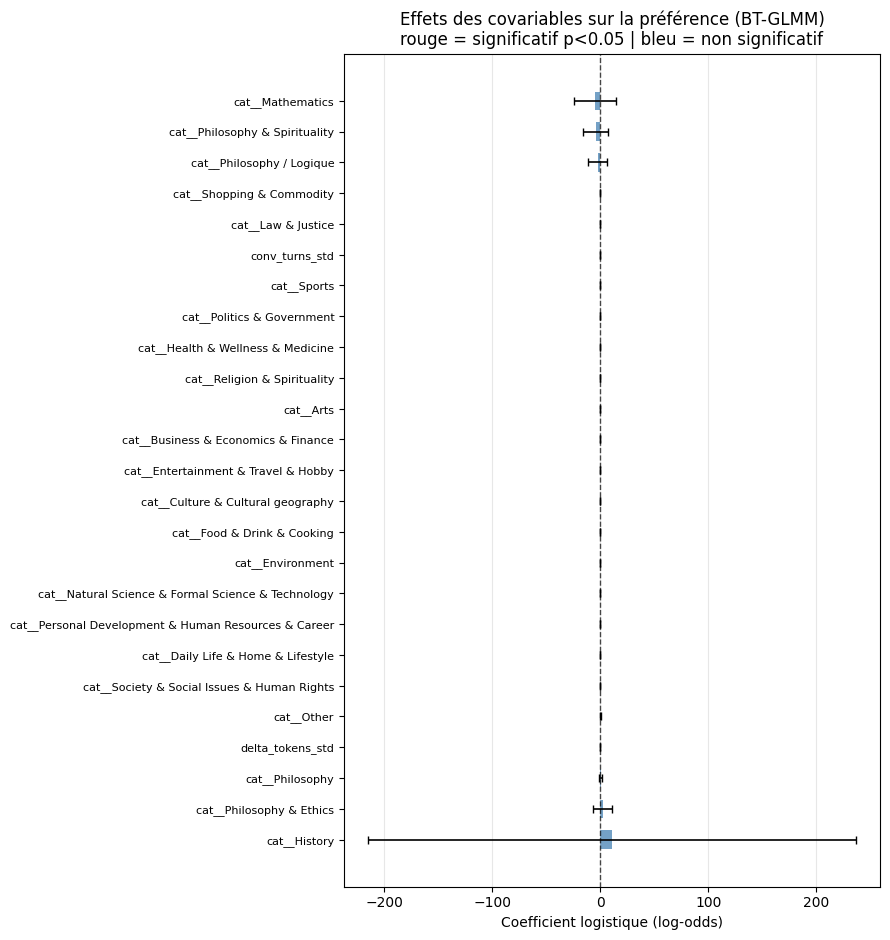


=== Odds Ratios des covariables numériques ===
conv_turns_std            γ=-0.0104  OR=0.9897  p=1.590e-01  ✗ non significatif
delta_tokens_std          γ=+0.2127  OR=1.2370  p=5.660e-101  ✓ significatif

Interprétation : OR > 1 → favorise model_a | OR < 1 → défavorise model_a
Les coefficients sont standardisés : γ correspond à 1 écart-type d'augmentation.


In [31]:
# ── 16. Tableau des effets des covariables ────────────────────────────────────
cov_names_num = ['conv_turns_std', 'delta_tokens_std']
cov_names_cat = [f'cat__{c}' for c in cat_names]
cov_names_all = cov_names_num + cov_names_cat

df_cov = pd.DataFrame({
    'covariable':   cov_names_all,
    'coefficient':  coefs[cov_names_all].values,
    'p_value':      pvals[cov_names_all].values,
    'ci_low':       conf.loc[cov_names_all, 'ci_low'].values,
    'ci_high':      conf.loc[cov_names_all, 'ci_high'].values,
    'significatif': pvals[cov_names_all].values < 0.05
})
df_cov = df_cov.sort_values('coefficient', ascending=False).reset_index(drop=True)

print("=== Effets des covariables (log-odds) ===")
display(df_cov)

# ── 17. Forest plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(4, len(df_cov) * 0.38)))

colors = ['tomato' if s else 'steelblue' for s in df_cov['significatif']]
y_pos  = np.arange(len(df_cov))

ax.barh(y_pos, df_cov['coefficient'], color=colors, alpha=0.75, height=0.6)
ax.errorbar(
    df_cov['coefficient'], y_pos,
    xerr=[
        (df_cov['coefficient'] - df_cov['ci_low']).clip(lower=0),
        (df_cov['ci_high'] - df_cov['coefficient']).clip(lower=0)
    ],
    fmt='none', color='black', lw=1.2, capsize=3
)
ax.axvline(0, color='black', lw=1, linestyle='--', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_cov['covariable'], fontsize=8)
ax.set_xlabel("Coefficient logistique (log-odds)")
ax.set_title(
    "Effets des covariables sur la préférence (BT-GLMM)\n"
    "rouge = significatif p<0.05 | bleu = non significatif"
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 18. Interprétation des odds ratios ───────────────────────────────────────
print("\n=== Odds Ratios des covariables numériques ===")
for cov in cov_names_num:
    gamma = coefs[cov]
    odds  = np.exp(gamma)
    sig   = '✓ significatif' if pvals[cov] < 0.05 else '✗ non significatif'
    print(f"{cov:25s} γ={gamma:+.4f}  OR={odds:.4f}  p={pvals[cov]:.3e}  {sig}")

print("\nInterprétation : OR > 1 → favorise model_a | OR < 1 → défavorise model_a")
print("Les coefficients sont standardisés : γ correspond à 1 écart-type d'augmentation.")


**Analyse des effets des covariables.**

**`delta_tokens_std` (γ = +0.213, OR = 1.237, p ≈ 6×10⁻¹⁰¹),  significatif**

C'est l'effet le plus robuste du modèle, avec une p-value extrêmement faible. Un OR de 1.237 signifie que lorsque le modèle A produit une réponse d'un écart-type plus longue que B (soit ~1 169 tokens de plus), ses chances de victoire augmentent de **24%**. Il s'agit du **verbosity bias** bien documenté dans la littérature sur les LLM arenas (Zheng et al., 2023) : les évaluateurs humains tendent à percevoir les réponses plus longues comme plus complètes et de meilleure qualité, indépendamment du contenu réel. C'est une limite méthodologique fondamentale des évaluations par préférence humaine.

**`conv_turns_std` (γ = −0.010, p = 0.159), non significatif**

Le nombre de tours de conversation n'influence pas significativement les préférences une fois contrôlé pour les modèles et les autres covariables. La longueur de l'échange ne détermine pas qui gagne.

**Covariables catégorielles :**

Les coefficients des catégories ne mesurent **pas** la créativité des modèles. Ils capturent un éventuel **biais de position** : dans une catégorie donnée, le modèle placé en position A est-il systématiquement avantagé par rapport à la catégorie de référence (Education) ?

Seules trois catégories sont significatives (p < 0.05) :
- `cat__Other` (γ = +0.163, p = 0.002) : léger avantage au modèle A
- `cat__Society & Social Issues` (γ = +0.096, p = 0.040) : effet modeste
- `cat__Natural Science & Technology` (γ = +0.057, p = 0.0003) : petit effet mais très significatif grâce au grand volume (18 041 votes)

Ces effets sont faibles en magnitude et probablement liés à des déséquilibres dans la composition des paires de modèles testées par catégorie.

**`cat__History` (γ = +10.89, p = 0.92) :** coefficient énorme mais totalement non significatif, avec un intervalle de confiance [−214 ; +236]. Cela reflète une **très faible volumétrie** pour cette catégorie : l'estimation est instable et inutilisable. #TODO : vérifier le nombre de votes dans cette catégorie.

### f. Modification des scores $\beta$ : comparaison BT classique vs GLMM 

Modèles communs BT / GLMM  : 97
Spearman ρ (BT vs GLMM)    : 0.9784  (p = 8.40e-67)


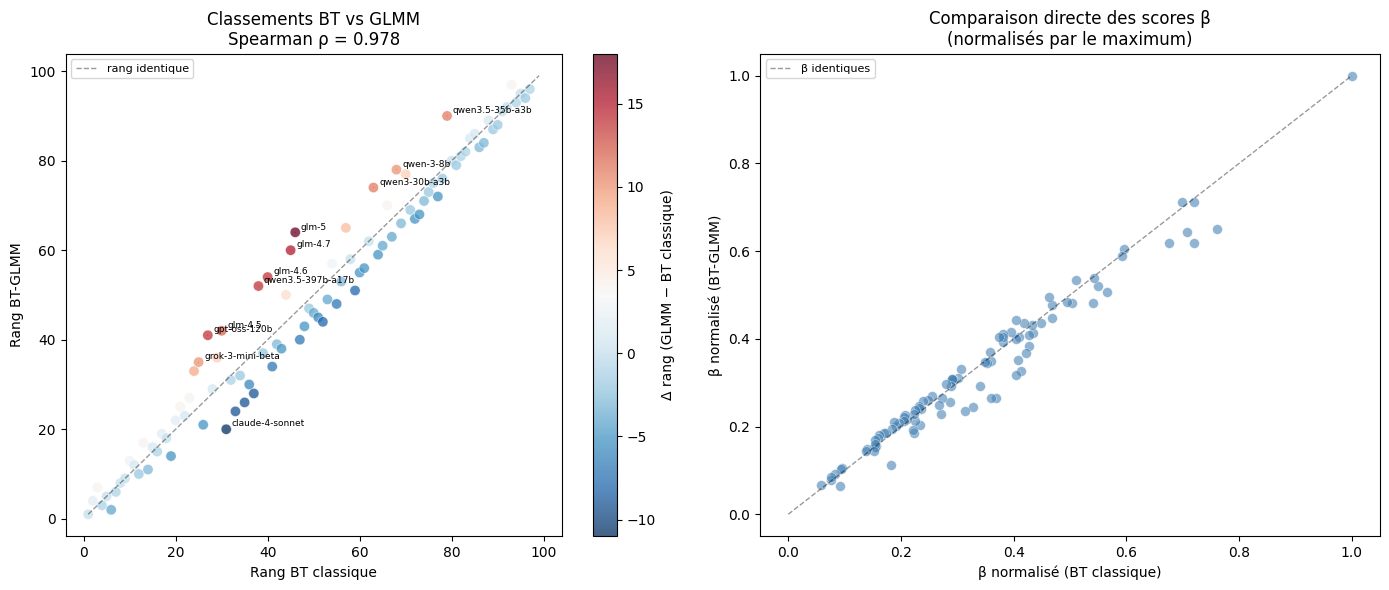


Modèles avec les plus grands écarts BT ↔ GLMM :


,model,rank_bt,rank_glmm,rank_diff
0,glm-5,46,64,18
1,glm-4.7,45,60,15
2,glm-4.6,40,54,14
3,qwen3.5-397b-a17b,38,52,14
4,gpt-oss-120b,27,41,14
5,glm-4.5,30,42,12
6,claude-4-sonnet,31,20,-11
7,qwen3.5-35b-a3b,79,90,11
8,qwen3-30b-a3b,63,74,11
9,grok-3-mini-beta,25,35,10


In [32]:
from scipy.stats import spearmanr

# ── 19. Jointure BT classique / GLMM sur les modèles communs ─────────────────
df_compare = (
    df_rank_global[['model', 'rank', 'beta']]
    .rename(columns={'rank': 'rank_bt', 'beta': 'beta_bt'})
    .merge(df_rank_glmm[['model', 'rank_glmm', 'beta_glmm']], on='model')
)

rho_cmp, pval_cmp = spearmanr(df_compare['rank_bt'], df_compare['rank_glmm'])
print(f"Modèles communs BT / GLMM  : {len(df_compare)}")
print(f"Spearman ρ (BT vs GLMM)    : {rho_cmp:.4f}  (p = {pval_cmp:.2e})")

df_compare['rank_diff'] = df_compare['rank_glmm'] - df_compare['rank_bt']
df_compare['abs_diff']  = df_compare['rank_diff'].abs()
threshold_glmm = df_compare['abs_diff'].nlargest(10).min()

# ── 20. Visualisation : deux graphiques côte à côte ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique gauche : rang BT vs rang GLMM
ax = axes[0]
sc = ax.scatter(
    df_compare['rank_bt'], df_compare['rank_glmm'],
    c=df_compare['rank_diff'], cmap='RdBu_r',
    s=55, alpha=0.75, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Δ rang (GLMM − BT classique)')
lim = max(df_compare[['rank_bt', 'rank_glmm']].max()) + 2
ax.plot([1, lim], [1, lim], 'k--', lw=1, alpha=0.4, label='rang identique')
for _, row in df_compare[df_compare['abs_diff'] >= threshold_glmm].iterrows():
    ax.annotate(
        row['model'], xy=(row['rank_bt'], row['rank_glmm']),
        fontsize=6.5, xytext=(4, 2), textcoords='offset points',
        arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.5)
    )
ax.set_xlabel("Rang BT classique")
ax.set_ylabel("Rang BT-GLMM")
ax.set_title(f"Classements BT vs GLMM\nSpearman ρ = {rho_cmp:.3f}")
ax.legend(fontsize=8)

# Graphique droit : scores β normalisés en regard direct
ax2 = axes[1]
beta_bt_norm   = df_compare['beta_bt']   / df_compare['beta_bt'].max()
beta_glmm_norm = df_compare['beta_glmm'] / df_compare['beta_glmm'].max()
ax2.scatter(
    beta_bt_norm, beta_glmm_norm,
    alpha=0.6, s=50, color='steelblue', edgecolors='white', linewidths=0.4
)
ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='β identiques')
ax2.set_xlabel("β normalisé (BT classique)")
ax2.set_ylabel("β normalisé (BT-GLMM)")
ax2.set_title("Comparaison directe des scores β\n(normalisés par le maximum)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 21. Tableau des modèles avec les plus grands écarts ──────────────────────
print("\nModèles avec les plus grands écarts BT ↔ GLMM :")
display(
    df_compare.sort_values('abs_diff', ascending=False)
              .head(12)[['model', 'rank_bt', 'rank_glmm', 'rank_diff']]
              .reset_index(drop=True)
)


**Analyse de la comparaison BT classique vs BT-GLMM.**

Le Spearman **ρ = 0.978** (p = 8.4×10⁻⁶⁷) est très élevé : contrôler pour les covariables contextuelles ne bouleverse pas le classement global. Deux interprétations complémentaires :

1. **Les covariables disponibles ne créent pas de biais majeur.** Les modèles ont été testés dans des conditions suffisamment homogènes pour que le BT classique soit une bonne approximation. Le ρ élevé valide rétrospectivement l'usage du BT classique en section 1.

2. **Certains modèles sont néanmoins affectés.** Les modèles GLM (glm-5, glm-4.7, glm-4.6, glm-4.5) **descendent tous de 12 à 18 rangs** avec le GLMM. Ces modèles bénéficiaient probablement du verbosity bias dans le BT classique (réponses plus longues que leurs adversaires), et leur rang GLMM, contrôlé pour la longueur, est plus bas. À l'inverse, **claude-4-sonnet** monte de 11 rangs : ce modèle est pénalisé par le BT brut car il produit des réponses plus courtes, mais sa qualité intrinsèque est mieux captée une fois la longueur contrôlée.

#### Synthèse de la section 3

Le modèle BT-GLMM apporte trois résultats principaux :

1. **Le verbosity bias est réel et statistiquement robuste** (OR = 1.24, p ≈ 10⁻¹⁰¹) : les modèles produisant des réponses plus longues sont systématiquement favorisés par les évaluateurs humains, indépendamment de leur qualité intrinsèque. Ce biais devrait être corrigé dans toute évaluation rigoureuse.

2. **Le contexte thématique a un impact faible mais non nul** sur les préférences. Les effets catégoriels significatifs sont de petite magnitude (γ < 0.17) et probablement liés à des déséquilibres de composition plutôt qu'à de vraies différences de compétence par domaine.

3. **Le classement global est robuste** (ρ = 0.978) : les modèles forts le restent après contrôle, ce qui renforce la validité des conclusions de la section 1. Les exceptions (famille GLM pénalisée, Claude favorisé) illustrent l'utilité du GLMM pour identifier les modèles dont le classement brut est biaisé par le verbosity.